In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

In [ ]:
from google.colab import drive
import pandas as pd

drive.mount('/content/drive')
dataset_path = '/content/drive/MyDrive/Dataset/phishing_url_dataset.csv'
df = pd.read_csv(dataset_path)
print("Ukuran dataset awal:", df.shape)
df.head()

Mounted at /content/drive
Ukuran dataset awal: (2488, 14)


,url_length,valid_url,at_symbol,sensitive_words_count,path_length,isHttps,nb_dots,nb_hyphens,nb_and,nb_or,nb_www,nb_com,nb_underscore,target
0,42,0,0,0,20,0,2,0,0,0,1,1,0,0
1,73,0,0,0,52,0,5,0,0,0,0,1,0,0
2,73,0,0,0,52,0,5,0,0,0,0,1,0,0
3,73,0,0,0,52,0,5,1,0,1,0,1,0,0
4,73,0,0,0,52,0,5,0,0,0,0,1,0,0


In [ ]:
print("Jumlah baris duplikat:", df.duplicated().sum())
df_clean = df.drop_duplicates().reset_index(drop=True)
print("Ukuran dataset setelah dedup:", df_clean.shape)

Jumlah baris duplikat: 1134
Ukuran dataset setelah dedup: (1354, 14)


url_length               0
valid_url                0
at_symbol                0
sensitive_words_count    0
path_length              0
isHttps                  0
nb_dots                  0
nb_hyphens               0
nb_and                   0
nb_or                    0
nb_www                   0
nb_com                   0
nb_underscore            0
target                   0
dtype: int64
target
0    905
1    449
Name: count, dtype: int64


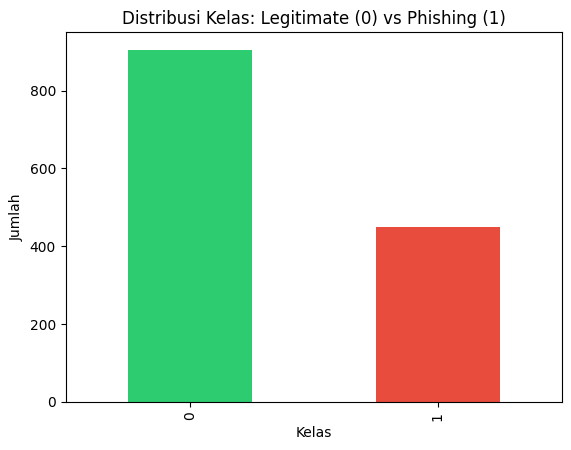

In [ ]:
print(df_clean.isnull().sum())
print(df_clean['target'].value_counts())

df_clean['target'].value_counts().plot(kind='bar', color=['#2ecc71','#e74c3c'])
plt.title('Distribusi Kelas: Legitimate (0) vs Phishing (1)')
plt.xlabel('Kelas')
plt.ylabel('Jumlah')
plt.show()

In [ ]:
print(df_clean.groupby('target').mean().round(2).T)

target                     0      1
url_length             49.57  56.28
valid_url               0.01   0.33
at_symbol               0.02   0.00
sensitive_words_count   0.11   0.24
path_length            16.32  13.46
isHttps                 0.25   0.34
nb_dots                 3.74   4.37
nb_hyphens              0.64   1.04
nb_and                  0.03   0.01
nb_or                   0.26   0.26
nb_www                  0.38   0.14
nb_com                  0.70   0.63
nb_underscore           0.18   0.10


valid_url                0.460547
nb_www                  -0.236648
url_length               0.157389
sensitive_words_count    0.151348
nb_dots                  0.136917
nb_hyphens               0.132982
isHttps                  0.099179
nb_underscore           -0.071685
path_length             -0.069729
nb_and                  -0.061097
nb_com                  -0.056809
at_symbol               -0.028234
nb_or                    0.000864
Name: target, dtype: float64


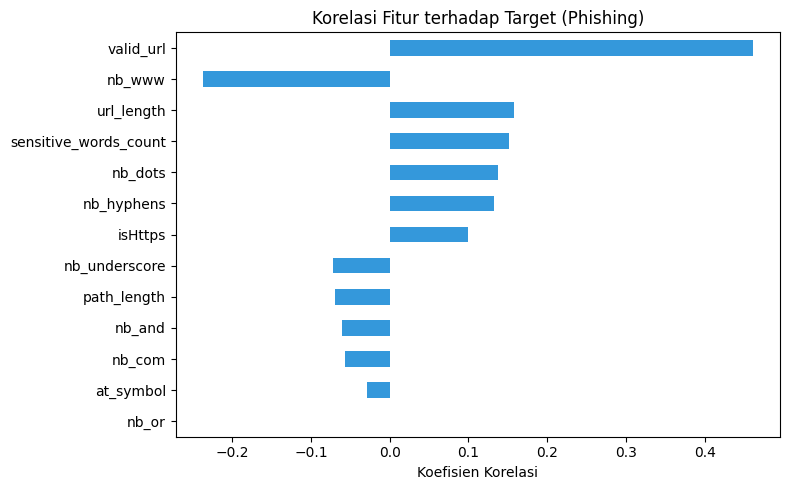

In [ ]:
corr = df_clean.corr(numeric_only=True)['target'].drop('target').sort_values(key=abs, ascending=False)
print(corr)

plt.figure(figsize=(8,5))
corr.plot(kind='barh', color='#3498db')
plt.title('Korelasi Fitur terhadap Target (Phishing)')
plt.xlabel('Koefisien Korelasi')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
X = df_clean.drop('target', axis=1)
y = df_clean['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Data latih:", X_train.shape[0], "| Data uji:", X_test.shape[0])

Data latih: 1083 | Data uji: 271


In [ ]:
# 1. Import semua model dan metrik yang dibutuhkan
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 2. Definisikan dictionary models (perhatikan tambahan 'models =')
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42, n_estimators=100),
    "XGBoost": XGBClassifier(random_state=42, eval_metric='logloss'),
}

results_list = []
predictions = {}

# 3. Jalankan perulangan
for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    predictions[name] = pred

    acc = accuracy_score(y_test, pred)
    prec = precision_score(y_test, pred)
    rec = recall_score(y_test, pred)
    f1 = f1_score(y_test, pred)

    results_list.append([name, acc*100, prec, rec, f1])

    print(f"\n=== {name} ===")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1-score:  {f1:.4f}")


=== Decision Tree ===
Accuracy:  0.7085
Precision: 0.5567
Recall:    0.6000
F1-score:  0.5775

=== Random Forest ===
Accuracy:  0.7675
Precision: 0.6667
Recall:    0.6000
F1-score:  0.6316

=== XGBoost ===
Accuracy:  0.7601
Precision: 0.6437
Recall:    0.6222
F1-score:  0.6328


In [ ]:
results_df = pd.DataFrame(results_list, columns=['Model', 'Accuracy (%)', 'Precision', 'Recall', 'F1-Score']).round(3)
print(results_df)

           Model  Accuracy (%)  Precision  Recall  F1-Score
0  Decision Tree        70.849      0.557   0.600     0.578
1  Random Forest        76.753      0.667   0.600     0.632
2        XGBoost        76.015      0.644   0.622     0.633


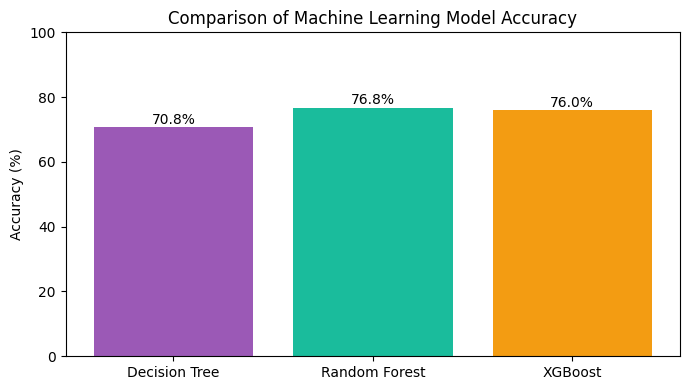

In [ ]:
plt.figure(figsize=(7,4))
plt.bar(results_df['Model'], results_df['Accuracy (%)'], color=['#9b59b6','#1abc9c','#f39c12'])
plt.title('Comparison of Machine Learning Model Accuracy')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 100)
for i, v in enumerate(results_df['Accuracy (%)']):
    plt.text(i, v+1, f"{v:.1f}%", ha='center')
plt.tight_layout()
plt.show()

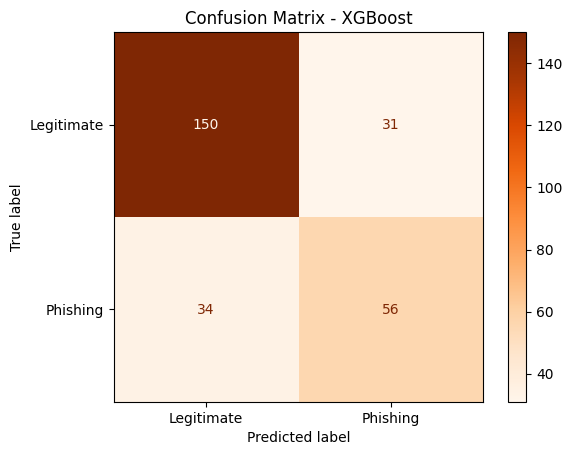

In [ ]:
cm = confusion_matrix(y_test, predictions["XGBoost"])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Legitimate','Phishing'])
disp.plot(cmap='Oranges')
plt.title('Confusion Matrix - XGBoost')
plt.show()

valid_url                0.576847
nb_www                   0.069551
sensitive_words_count    0.057178
nb_hyphens               0.046023
path_length              0.038984
nb_dots                  0.038070
isHttps                  0.037923
nb_or                    0.035045
nb_com                   0.028637
nb_underscore            0.028120
url_length               0.026732
nb_and                   0.016890
at_symbol                0.000000
dtype: float32


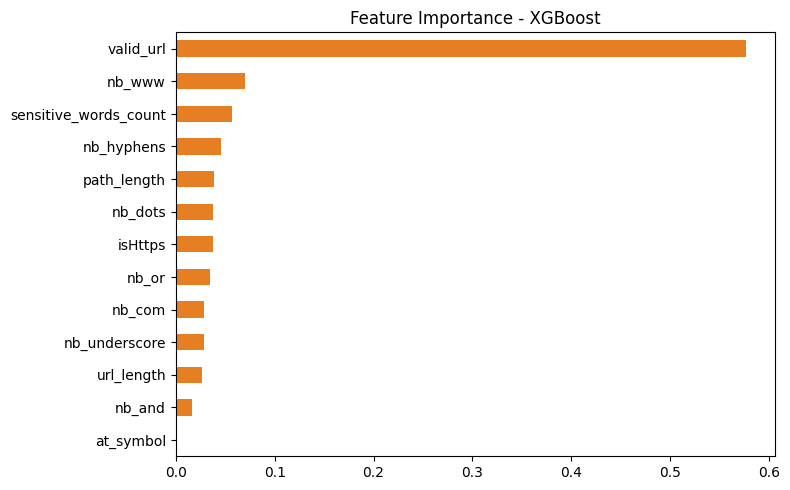

In [ ]:
xgb_model = models["XGBoost"]
importances = pd.Series(xgb_model.feature_importances_, index=X.columns).sort_values(ascending=False)
print(importances)

plt.figure(figsize=(8,5))
importances.plot(kind='barh', color='#e67e22')
plt.title('Feature Importance - XGBoost')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()